<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão desviada

### Problema 6

Considere a viga fabricada com um perfil INP 100, ao qual foi soldada a barra horizontal DE como indicado na figura. No ponto E está aplicada, a força $F$ = 15 kN numa direção paralela ao eixo da viga. Determine a distribuição de tensões normais na secção ABC, com a posição do eixo neutro e os valores da tensão máxima e mínima.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au03/P6/MSII_Au03_P6.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução

### Perfil INP 100

[Tabela com dimensões de perfis europeus](https://userweb.fct.unl.pt/~pgc/ms2/perfis%20europeus.pdf)

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au03/P6/IPN100.png"
style="max-width: 100%;"/>

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
# Create an empty classclass varin: pass

from dataclasses import dataclass

@dataclass
class Varin:
    A: float
    d: float
    b: float
    bf: float
    tf: float
    tw: float
    Ix: float
    Wx: float
    ix: float
    Iy: float
    Wy: float
    iy: float

INP100 = Varin(A=1060., d=100., b=42., bf=50., tf=6.8, tw=4.5, Ix=1.71*1e6, Wx=34.2*1e3, ix=40.1, Iy=0.122*1e6, Wy=4.9*1e3, iy=10.7)
print(vars(INP100))

{'A': 1060.0, 'd': 100.0, 'b': 42.0, 'bf': 50.0, 'tf': 6.8, 'tw': 4.5, 'Ix': 1710000.0, 'Wx': 34200.0, 'ix': 40.1, 'Iy': 122000.0, 'Wy': 4900.0, 'iy': 10.7}


#### Caso geral de carregamento excêntrico

A acção de uma força excênctica $P$ sobre a viga é estaticamente equivalente a um sistema constituído por pela força $P$ aplicada no centróide da secção e dois binários de momentos que a força $P$ exerce em relação ao centroide da secção sobre os eixos $y$ e $z$.

Pelo princípio de Saint-Venant, pode substituir-se o carregamento original (carga excêntrica) pelo carregamento equivalente (carga centrada + momentos) sempre que se pretender determinar a distribuição de tensões numa secção suficientemente afastada das extremidades da barra.

Pelo princípio da sobreposição, a distribuição de tensões normais na secção será dada por:

- Tensões devidas ao carregamento axial com as tensões devidas à flexão

\begin{equation*}
\sigma_{xx} = \frac{N}{A} - \frac{M_z}{I_z}y + \frac{M_y}{I_y} z
\end{equation*}

em que $y$ e $z$ são medidos em relação aos eixos principais de inércia da secção. A expressão mostra que a distribuição das tensões ao longo da secção é linear.
em que $y$ e $z$ são medidos em relação aos eixos principais de inércia da secção. A expressão mostra que a distribuição das tensões ao longo da secção é linear.

Ao calcular a tensão combinada $\sigma_{xx}$ da equação acima, é necessário certificar o sinal correto de cada um dos três termos no segundo membro, uma vez que cada um pode ser positivo ou negativo, dependendo do sentido do carrgamento (tração ou compressão) e da posição da linha de ação da força excêntrica em relação aos eixos principais de inércia da secção:

\begin{equation*}
\sigma_{xx} = \pm \frac{N}{A} \pm \frac{M_z}{I_z}y \pm \frac{M_y}{I_y} z
\end{equation*}

- A força excêntrica é substituida por um sistema equivalente
 que consiste numa carga central e dois momentos segundo $y$ e $z$.

In [2]:
# units SI: N, m, Pa
# Data ############################
br = .2 # unit: m
N = 15.*1e3 # unit: N
###################################
snorm = N/INP100.A*1e6 # N/m2
print(f'N/A = {snorm*1e-6:.2f} MPa')
# Moments about Z axis
Mz = -N*INP100.d*1e-3/2  # unit: N.m
print(f'Mz  = {Mz:.1f} N.m')
# Moments about Y axis
My = -N*br # unit: N.m
print(f'My  = {My:.1f} N.m')

N/A = 14.15 MPa
Mz  = -750.0 N.m
My  = -3000.0 N.m


Resultando,

\begin{equation*}
\sigma_{xx}(y,z) = \frac{N}{A} - \frac{(-M_z)}{I_z}y + \frac{(-M_y)}{I_y} z
\end{equation*}


In [3]:
Iz = INP100.Ix*1e-12 # unit m4
Iy = INP100.Iy*1e-12

import sympy as sy
def printsym(expr):
    return expr.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

y, z = sy.symbols('y z')

if N > 0:
    EQ = snorm - Mz/Iz*y + My/Iy*z
else:
    EQ = snorm + Mz/Iz*y - My/Iy*z
print(f' Sxx = {printsym(EQ*1e-6)} [MPa]')

 Sxx = 438.596*y - 24590.164*z + 14.151 [MPa]


In [4]:
def evalsxx(i,j):
    return EQ.subs([(z,i),(y,j)])*1e-6 # MPa

A = (-INP100.bf/2,(INP100.d/2)) # unit: m
SxxA = evalsxx(A[0]*1e-3,A[1]*1e-3) #EQ.subs([(z,A[0]),(y,A[1])])*1e-6 # Pa > MPa
print(f'Point A({A[0]},{A[1]}) mm : sigxx = {SxxA:.2f} MPa')

Point A(-25.0,50.0) mm : sigxx = 650.83 MPa


In [5]:

B = (INP100.bf/2,(INP100.d/2)) # unit: m
SxxB = evalsxx(B[0]*1e-3,B[1]*1e-3) #EQ.subs([(z,A[0]),(y,A[1])])*1e-6 # Pa > MPa
print(f'Point B({B[0]},{B[1]}) mm : sigxx = {SxxB:.2f} MPa')


Point B(25.0,50.0) mm : sigxx = -578.67 MPa


In [6]:
C = (INP100.bf/2,-(INP100.d/2)) # unit: m
SxxC = evalsxx(C[0]*1e-3,C[1]*1e-3) #EQ.subs([(z,A[0]),(y,A[1])])*1e-6 # Pa > MPa
print(f'Point C({C[0]},{C[1]}) mm : sigxx = {SxxC:.2f} MPa')

Point C(25.0,-50.0) mm : sigxx = -622.53 MPa


In [7]:
D = (-INP100.bf/2,-(INP100.d/2)) # unit: m
SxxD = evalsxx(D[0]*1e-3,D[1]*1e-3) #EQ.subs([(z,A[0]),(y,A[1])])*1e-6 # Pa > MPa
print(f'Point D({D[0]},{D[1]}) mm : sigxx = {SxxD:.2f} MPa')


Point D(-25.0,-50.0) mm : sigxx = 606.98 MPa


In [8]:

E = (0,INP100.d/2) # unit: m
SxxE = evalsxx(E[0]*1e-3,E[1]*1e-3) #EQ.subs([(z,A[0]),(y,A[1])])*1e-6 # Pa > MPa
print(f'Point E({E[0]},{E[1]}) mm : sigxx = {SxxE:.2f} MPa')


Point E(0,50.0) mm : sigxx = 36.08 MPa


In [9]:

F = (0,-INP100.d/2) # unit: m
SxxF = evalsxx(F[0]*1e-3,F[1]*1e-3) #EQ.subs([(z,A[0]),(y,A[1])])*1e-6 # Pa > MPa
print(f'Point G({F[0]},{F[1]}) mm : sigxx = {SxxF:.2f} MPa')

Point G(0,-50.0) mm : sigxx = -7.78 MPa


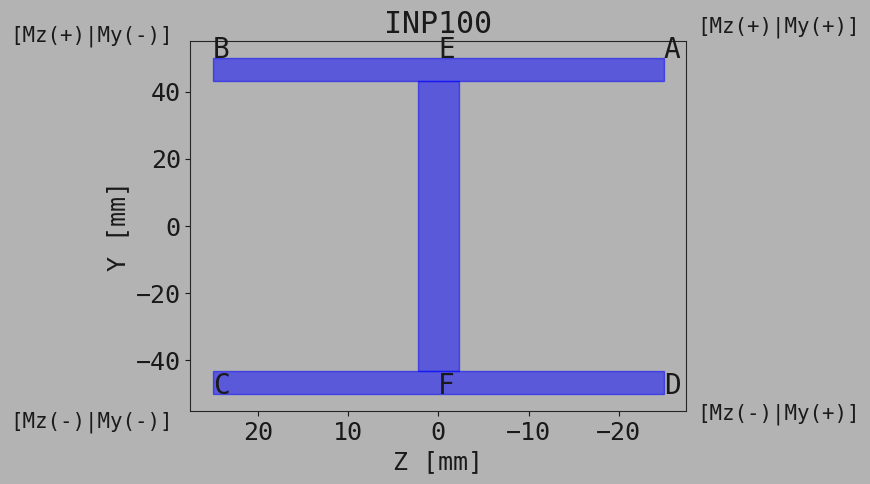

In [10]:

import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# local coordinate system at centroid of the cross-section
sZ, sY = -INP100.bf/2, -INP100.d/2-INP100.tf

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((sZ,sY+INP100.tf),INP100.bf,INP100.tf,color="blue",alpha=0.5))
ax.add_patch(Rectangle((sZ+INP100.bf/2-INP100.tw/2,sY+2*INP100.tf),INP100.tw,INP100.d-2*INP100.tf,color="blue",alpha=0.5))
ax.add_patch(Rectangle((sZ,INP100.d/2-INP100.tf),INP100.bf,INP100.tf,color="blue",alpha=0.5))
plt.text(A[0],A[1],'A', fontsize=20)
plt.text(A[0]*1.15,A[1]*1.15,'[Mz(+)|My(+)]', fontsize=15)
plt.text(B[0],B[1],'B', fontsize=20)
plt.text(B[0]*1.9,B[1]*1.1,'[Mz(+)|My(-)]', fontsize=15)
plt.text(C[0],C[1],'C', fontsize=20)
plt.text(C[0]*1.9,C[1]*1.2,'[Mz(-)|My(-)]', fontsize=15)
plt.text(D[0],D[1],'D', fontsize=20)
plt.text(D[0]*1.15,D[1]*1.15,'[Mz(-)|My(+)]', fontsize=15)
plt.text(E[0],E[1],'E', fontsize=20)
plt.text(F[0],F[1],'F', fontsize=20)
ax.invert_xaxis()
plt.xlabel("Z [mm]")
plt.ylabel("Y [mm]")
plt.title("INP100")
plt.show()

Sxx AB  |  y = 50.0 [mm]
:::::::::::::::::::::::::::::::::::::::::::::::::
SxxAB (z) = 36080767.9576299 - 24590163934.4262*z
Sxx = 0 : z = 1.467 mm
:::::::::::::::::::::::::::::::::::::::::::::::::


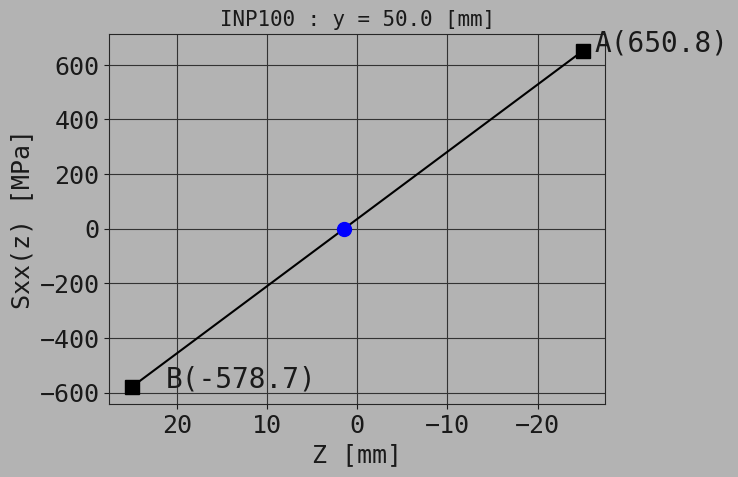

In [11]:
print(f'Sxx AB  |  y = {INP100.d/2} [mm]')
print(':::::::::::::::::::::::::::::::::::::::::::::::::')
zAB = np.linspace(-INP100.bf/2,INP100.bf/2)
yAB = np.ones(len(zAB))*INP100.d/2
SxxAB = np.zeros(len(zAB))
for k in range(0,len(zAB)):
    SxxAB[k] = evalsxx(zAB[k]*1e-3,yAB[k]*1e-3)

print(f'SxxAB (z) = {EQ.subs(y,INP100.d/2*1e-3)}')
sol2 = solve(EQ.subs(y,INP100.d/2*1e-3), z)
zSxx0AB = sol2[0]*1e3
print(f'Sxx = 0 : z = {zSxx0AB:.3f} mm')
print(':::::::::::::::::::::::::::::::::::::::::::::::::')

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.plot(zAB,SxxAB,color="black")
ax.plot(zSxx0AB,EQ.subs([(z,zSxx0AB*1e-3),(y,INP100.d/2*1e-3)]),'ob',markersize=10)
ax.plot(A[0],SxxA,'sk',markersize=10)
plt.text(A[0]*1.05,evalsxx(A[0]*1e-3,INP100.d/2*1e-3),f'A({SxxA:.1f})', fontsize=20)
ax.plot(B[0],SxxB,'sk',markersize=10)
plt.text(B[0]*.85,evalsxx(B[0]*1e-3,INP100.d/2*1e-3),f'B({SxxB:.1f})', fontsize=20)
ax.invert_xaxis()
plt.xlabel("Z [mm]")
plt.ylabel(f"Sxx(z) [MPa]")
plt.title(f"INP100 : y = {INP100.d/2:.1f} [mm]",fontsize=15)
plt.grid()
plt.show()

Sxx CD | y = -50.0 [mm]:
:::::::::::::::::::::::::::::::::::::::::::::::::
SxxCD (z) = -24590163934.4262*z - 7778881.1651771
Sxx = 0 : z = -0.316 mm
:::::::::::::::::::::::::::::::::::::::::::::::::


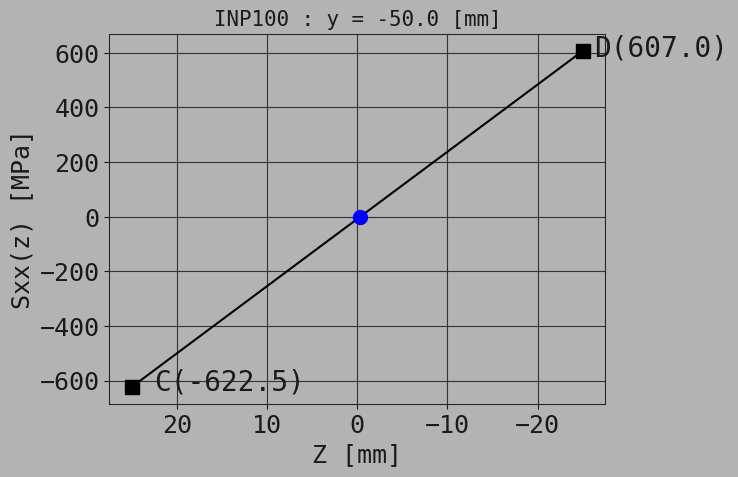

In [12]:
print(f'Sxx CD | y = {-INP100.d/2} [mm]:')
print(':::::::::::::::::::::::::::::::::::::::::::::::::')
zCD = np.linspace(-INP100.bf/2,INP100.bf/2)
yCD = -np.ones(len(zCD))*INP100.d/2
SxxCD = np.zeros(len(zCD))
for k in range(0,len(zCD)):
    SxxCD[k] = evalsxx(zCD[k]*1e-3,yCD[k]*1e-3)

print(f'SxxCD (z) = {EQ.subs(y,-INP100.d/2*1e-3)}')
sol3 = solve(EQ.subs(y,-INP100.d/2*1e-3), z)
zSxx0CD = sol3[0]*1e3
print(f'Sxx = 0 : z = {zSxx0CD:.3f} mm')
print(':::::::::::::::::::::::::::::::::::::::::::::::::')

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.plot(zCD,SxxCD,color="black")
ax.plot(zSxx0CD,EQ.subs([(z,zSxx0CD*1e-3),(y,-INP100.d/2*1e-3)]),'ob',markersize=10)
ax.plot(C[0],SxxC,'sk',markersize=10)
plt.text(C[0]*.9,evalsxx(C[0]*1e-3,INP100.d/2*1e-3)*1.1,f'C({SxxC:.1f})', fontsize=20)
ax.plot(D[0],SxxD,'sk',markersize=10)
plt.text(D[0]*1.05,evalsxx(D[0]*1e-3,INP100.d/2*1e-3)*.9,f'D({SxxD:.1f})', fontsize=20)
ax.invert_xaxis()
plt.xlabel("Z [mm]")
plt.ylabel(f"Sxx(z) [MPa]")
plt.title(f"INP100 : y = {-INP100.d/2:.1f} [mm]",fontsize=15)
plt.grid()
plt.show()

Sxx Alma (EF) | z = 0 [mm]:
:::::::::::::::::::::::::::::::::::::::::::::::::
SxxEF (y) = 438596491.22807*y + 14150943.3962264
Sxx = 0 : y = -32.264 mm
:::::::::::::::::::::::::::::::::::::::::::::::::


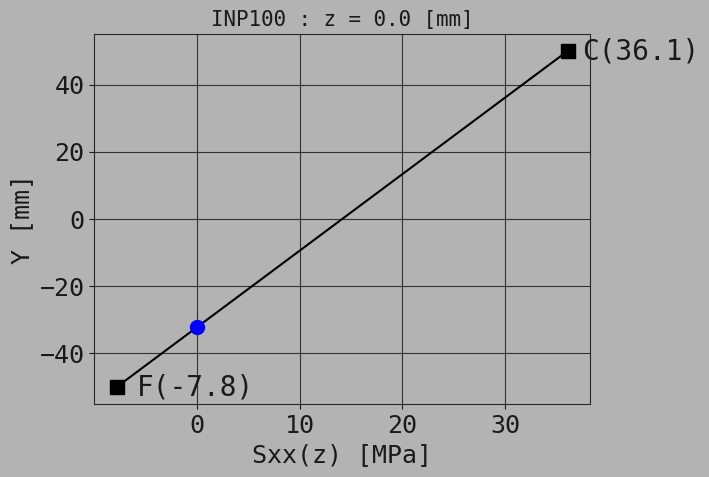

In [13]:
print(f'Sxx Alma (EF) | z = {0} [mm]:')
print(':::::::::::::::::::::::::::::::::::::::::::::::::')

yAlma = np.linspace(-INP100.d/2,INP100.d/2)
zAlma = np.zeros(len(yAlma))
SxxAlma = np.zeros(len(yAlma))
for k in range(0,len(zAB)):
    SxxAlma[k] = evalsxx(zAlma[k]*1e-3,yAlma[k]*1e-3)

print(f'SxxEF (y) = {EQ.subs(z,0)}')
sol4 = solve(EQ.subs(z,0), y)
ySxx0EF = sol4[0]*1e3
print(f'Sxx = 0 : y = {ySxx0EF:.3f} mm')
print(':::::::::::::::::::::::::::::::::::::::::::::::::')

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.plot(SxxAlma,yAlma,color="black")
ax.plot(EQ.subs([(z,0),(y,ySxx0EF*1e-3)]),ySxx0EF,'ob',markersize=10)
ax.plot(SxxE,E[1],'sk',markersize=10)
plt.text(SxxE*1.04,E[1]*.95,f'C({SxxE:.1f})', fontsize=20)
ax.plot(SxxF,F[1],'sk',markersize=10)
plt.text(SxxF*.75,F[1]*1.05,f'F({SxxF:.1f})', fontsize=20)
#ax.invert_xaxis()
plt.xlabel(f"Sxx(z) [MPa]")
plt.ylabel("Y [mm]")
plt.title(f"INP100 : z = {0:.1f} [mm]",fontsize=15)
plt.grid()
plt.show()

### Posição do eixo neutro

- A identificação do Eixo Neutro é obtida considrando a solução: $\sigma_{xx} = 0$.

\begin{equation*}
\frac{N}{A} - \frac{M_z}{I_z}y + \frac{M_y}{I_y} z = 0
\end{equation*}

A expressão anterior representa a equação de uma reta no plano ($z,y$).

- Qual é o efeito de uma carga axial ($N$), de tração ou de compressão, na localização do eixo neutro na área de secção?
- Qual é o efeito dos coeficientes $M_z/I_z$ e $M_y/I_y$ das coordenadas $y$ e $z$, respetivamente na orientação (rotação) do eixo neutro?

In [14]:
print(f'Sxx = {printsym(EQ)} [Pa]')
print(f'    = {printsym(EQ*1e-6)} [MPa]')
sol = solve(EQ, y)
yfun = sol[0]
print(f'  y = {printsym(yfun)} [m]')
print(f'    = {printsym(yfun*1e3)} [mm]')

Sxx = 438596491.228*y - 24590163934.426*z + 14150943.396 [Pa]
    = 438.596*y - 24590.164*z + 14.151 [MPa]
  y = 56.066*z - 0.032 [m]
    = 56065.574*z - 32.264 [mm]


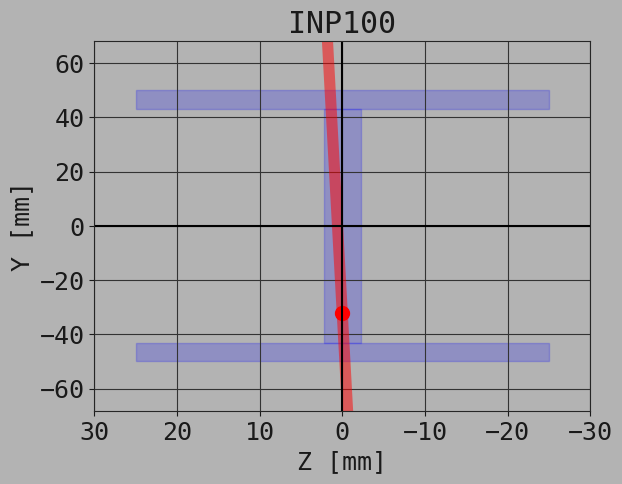

In [15]:
# coef. of the linear polynomial
a1 = yfun.subs(z,0)
a2 = yfun.subs(z,1)

zplo_mm = np.linspace(-INP100.bf/2,INP100.bf/2,100)
yplo_mm = np.zeros(len(zplo_mm))
for i in range(0,len(zplo_mm)):
    yplo_mm[i] = yfun.subs(z,zplo_mm[i]*1e-3)*1e3

# local coordinate system at centroid of the cross-section
sZ, sY = -INP100.bf/2, -INP100.d/2-INP100.tf
fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((sZ,sY+INP100.tf),INP100.bf,INP100.tf,color="blue",alpha=0.2))
ax.add_patch(Rectangle((sZ+INP100.bf/2-INP100.tw/2,sY+2*INP100.tf),INP100.tw,INP100.d-2*INP100.tf,color="blue",alpha=0.2))
ax.add_patch(Rectangle((sZ,INP100.d/2-INP100.tf),INP100.bf,INP100.tf,color="blue",alpha=0.2))
ax.plot(0,yfun.subs(z,0)*1e3,'or',markersize=10)
plt.xlabel("Z [mm]")
plt.ylabel("Y [mm]")
plt.title("INP100")
# make a plot with different y-axis using second axis object
ax.plot(zplo_mm,yplo_mm,'r-',linewidth=8,alpha=0.5)
ax.invert_xaxis()
plt.xlim([-sZ*1.2, sZ*1.2])
plt.ylim([sY*1.2, -sY*1.2])
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
ax.grid()
plt.show()

- Se o braço de 200 m diminuir, em que nova posição estará o eixo neutro?
- Um aumento da componente $M_y$ em relação a $M_z$, que efeitos tem sobre a rotação do eixo neutro?
- Qual é o efeito da magnitude e sentido da força axial na posição do eixo neutro?

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>